<a href="https://colab.research.google.com/github/SANTHIYAM306/mlops_training_tasks/blob/main/titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [50]:
import pandas as pd

# Load CSV file
df = pd.read_csv("titanic.csv")

# Select required columns
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]

# Fill missing Age values
df['Age'] = df['Age'].fillna(df['Age'].median())

# Convert Sex to numeric
df['Sex'] = df['Sex'].map({
    'male': 0,
    'female': 1
})

# Display processed data
print(df.head())

   Survived  Pclass  Sex   Age     Fare
0         0       3    0  22.0   7.2500
1         1       1    1  38.0  71.2833
2         1       3    1  26.0   7.9250
3         1       1    1  35.0  53.1000
4         0       3    0  35.0   8.0500


In [51]:
# Features (input variables)
X = df[['Pclass', 'Sex', 'Age', 'Fare']]

# Target (output variable)
y = df['Survived']

print("X (Features):")
print(X.head())

print("\ny (Target):")
print(y.head())

X (Features):
   Pclass  Sex   Age     Fare
0       3    0  22.0   7.2500
1       1    1  38.0  71.2833
2       3    1  26.0   7.9250
3       1    1  35.0  53.1000
4       3    0  35.0   8.0500

y (Target):
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64


In [52]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (712, 4)
X_test shape: (179, 4)
y_train shape: (712,)
y_test shape: (179,)


In [53]:
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree model
model = DecisionTreeClassifier(random_state=42)

# Train the model
model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [54]:
# Predict survival for test data
y_pred = model.predict(X_test)

# Show first 10 predictions
print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
[0 1 1 1 1 0 1 0 0 1]


Confusion Matrix:
[[78 27]
 [21 53]]


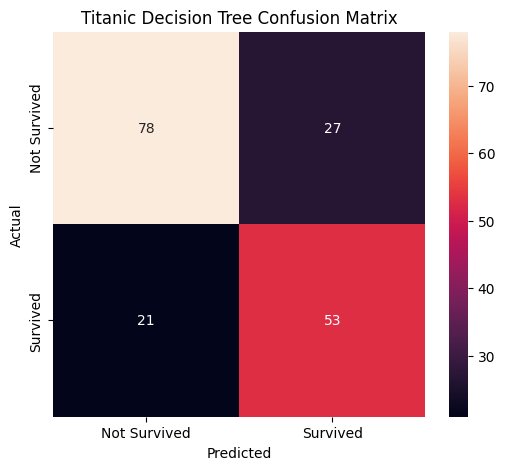

In [55]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Plot heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='rocket',
    xticklabels=['Not Survived', 'Survived'],
    yticklabels=['Not Survived', 'Survived']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Titanic Decision Tree Confusion Matrix')
plt.show()

In [64]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=4,
    random_state=40
)

# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Improved Accuracy:", accuracy)
print("Improved Model Score:", model.score(X_test, y_test))

Improved Accuracy: 0.7988826815642458
Improved Model Score: 0.7988826815642458
